# Random Forest

## Overview
Random Forest is an **ensemble** method that builds many Decision Trees and combines their predictions. It fixes the core weakness of a single tree — high variance — through two key ideas:

### 1. Bagging (Bootstrap Aggregating)
Each tree is trained on a **random bootstrap sample** (with replacement) of the training data.

### 2. Feature Randomness
At each split, only a **random subset of features** is considered (sqrt(n) for classification, n/3 for regression).

### Prediction:
- **Classification** → majority vote across all trees
- **Regression** → average prediction across all trees

### Why it works — the bias-variance decomposition:
$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- Single deep tree: low bias, **high variance**
- Random Forest: low bias, **low variance** (averaging decorrelated trees cancels out variance)

---
### Topics Covered
1. Bagging intuition — wisdom of crowds
2. Effect of n_estimators (number of trees)
3. Decision boundary vs single tree
4. Out-of-Bag (OOB) error estimation
5. Feature importance (MDI and Permutation)
6. Hyperparameter tuning with GridSearchCV
7. Random Forest Regressor
8. Real-world offline-safe dataset
9. Full model evaluation
10. Random Forest vs Decision Tree comparison


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_classification, make_regression

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Bagging Intuition — Wisdom of Crowds

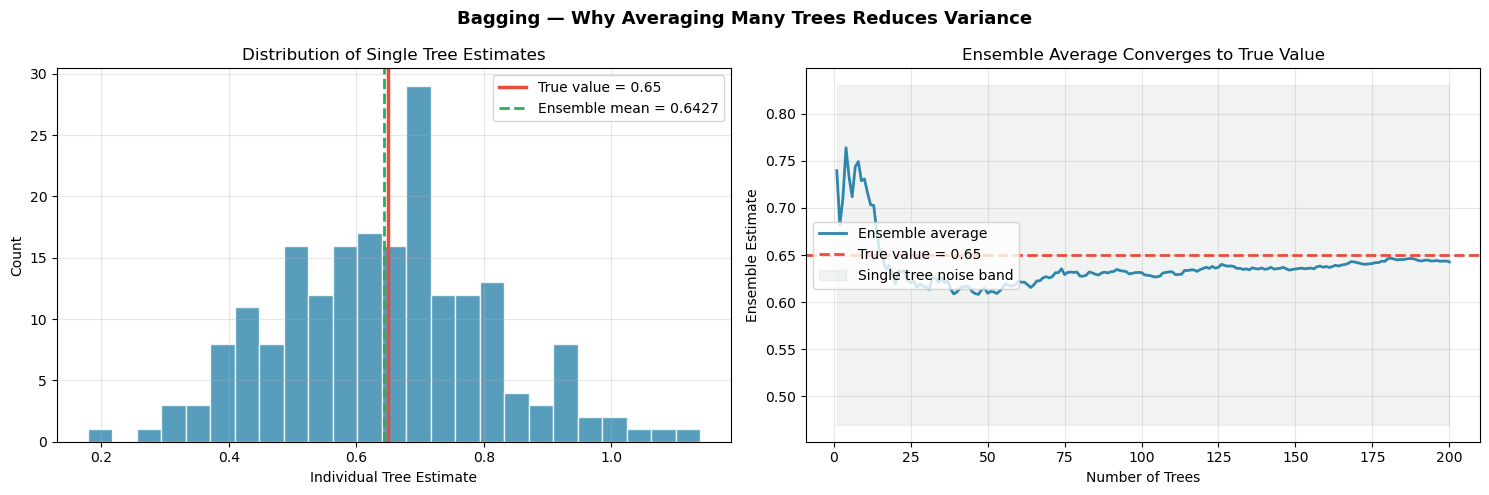

Single tree std dev : 0.1672
Ensemble std dev    : 0.0254
Variance reduction  : 84.8%


In [2]:
# Simulate bagging: average of noisy estimators beats any single one
np.random.seed(42)
true_value  = 0.65          # true probability we want to estimate
n_trees     = 200
noise_std   = 0.18

single_estimates  = true_value + np.random.randn(n_trees) * noise_std
ensemble_estimate = np.cumsum(single_estimates) / np.arange(1, n_trees+1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of individual estimates
axes[0].hist(single_estimates, bins=25, color=COLORS['primary'], edgecolor='white', alpha=0.8)
axes[0].axvline(true_value,              color=COLORS['danger'],  linewidth=2.5, label=f'True value = {true_value}')
axes[0].axvline(single_estimates.mean(), color=COLORS['success'], linewidth=2, linestyle='--',
                label=f'Ensemble mean = {single_estimates.mean():.4f}')
axes[0].set_xlabel('Individual Tree Estimate')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Single Tree Estimates')
axes[0].legend()

# Running ensemble average converging
axes[1].plot(range(1, n_trees+1), ensemble_estimate,
             color=COLORS['primary'], linewidth=2, label='Ensemble average')
axes[1].axhline(true_value, color=COLORS['danger'], linewidth=2, linestyle='--', label=f'True value = {true_value}')
axes[1].fill_between(range(1, n_trees+1),
                     true_value - noise_std, true_value + noise_std,
                     alpha=0.1, color=COLORS['neutral'], label='Single tree noise band')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('Ensemble Estimate')
axes[1].set_title('Ensemble Average Converges to True Value')
axes[1].legend()

plt.suptitle('Bagging — Why Averaging Many Trees Reduces Variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Single tree std dev : {single_estimates.std():.4f}')
print(f'Ensemble std dev    : {ensemble_estimate.std():.4f}')
print(f'Variance reduction  : {(1 - ensemble_estimate.std()/single_estimates.std())*100:.1f}%')

## 3. Generate Dataset & Fit Random Forest

In [3]:
np.random.seed(42)

X, y = make_classification(
    n_samples=600, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=None,
    oob_score=True, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'n_estimators      : {rf.n_estimators}')
print(f'Max features/split: {rf.max_features}')
print(f'OOB Score         : {rf.oob_score_:.4f}')
print(f'Test Accuracy     : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, y_prob):.4f}')

n_estimators      : 100
Max features/split: sqrt
OOB Score         : 0.9625
Test Accuracy     : 0.9667
Test ROC-AUC      : 0.9918


## 4. Decision Boundary — Random Forest vs Single Decision Tree

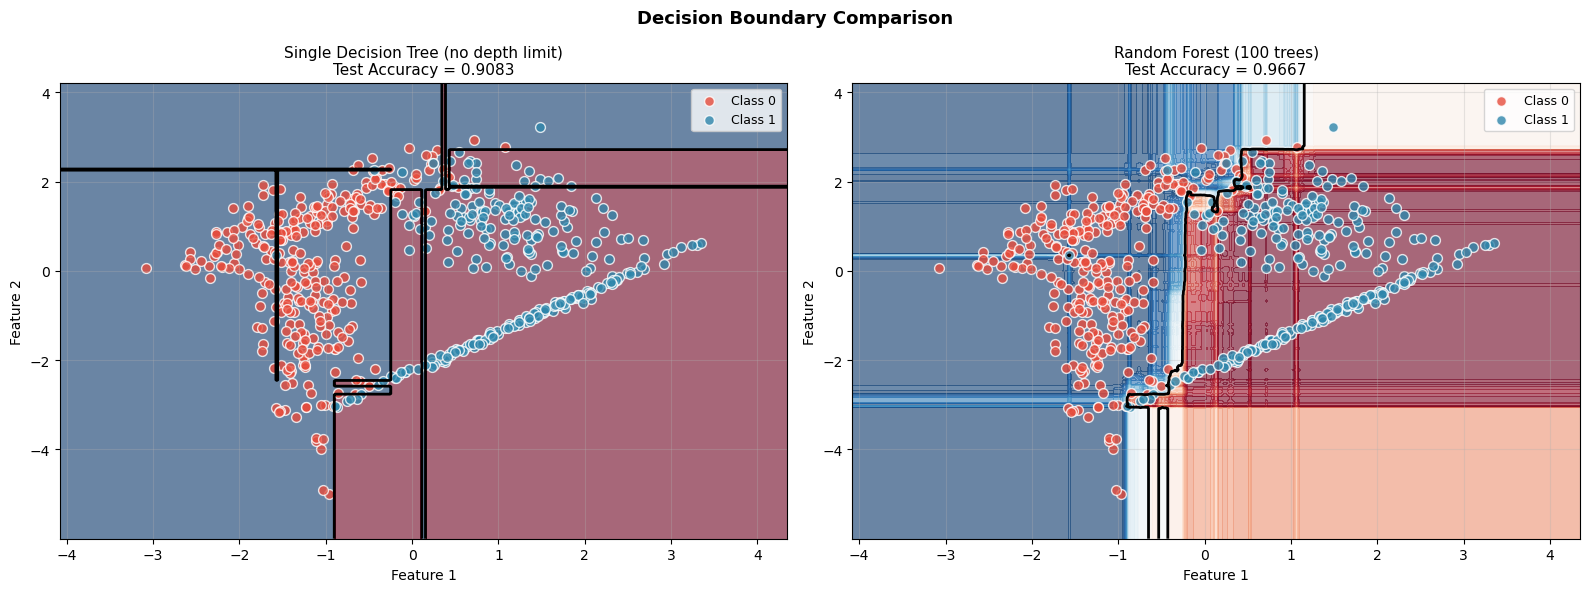

Single Tree: jagged, fragmented boundaries -> overfitting
Random Forest: smooth, stable boundaries  -> better generalization


In [4]:
single_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree.fit(X_train, y_train)

x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_rf   = rf.predict_proba(grid)[:, 1].reshape(xx.shape)
Z_tree = single_tree.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, Z, title, acc in zip(
    axes,
    [Z_tree, Z_rf],
    ['Single Decision Tree (no depth limit)', 'Random Forest (100 trees)'],
    [accuracy_score(y_test, single_tree.predict(X_test)),
     accuracy_score(y_test, rf.predict(X_test))]
):
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
               edgecolors='white', s=50, alpha=0.8, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
               edgecolors='white', s=50, alpha=0.8, label='Class 1')
    ax.set_title(f'{title}\nTest Accuracy = {acc:.4f}', fontsize=11)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend(fontsize=9)

plt.suptitle('Decision Boundary Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Single Tree: jagged, fragmented boundaries -> overfitting')
print('Random Forest: smooth, stable boundaries  -> better generalization')

## 5. Effect of n_estimators (Number of Trees)

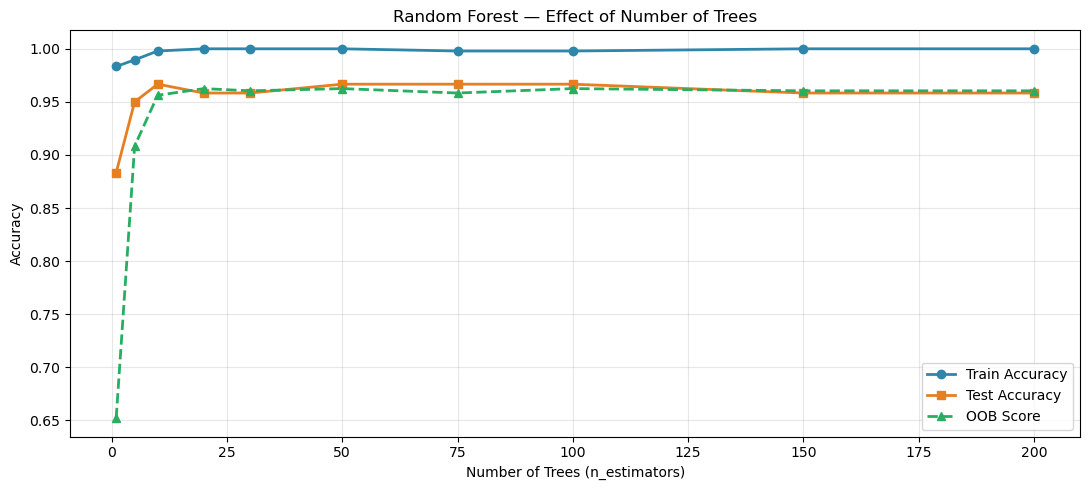

More trees -> lower variance -> accuracy stabilizes.
Beyond ~100 trees, gains are usually marginal but computation keeps growing.
OOB Score at 100 trees: 0.9625


In [5]:
n_trees_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_accs    = []
test_accs     = []
oob_scores    = []

for n in n_trees_range:
    clf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append( accuracy_score(y_test,  clf.predict(X_test)))
    oob_scores.append(clf.oob_score_)

plt.figure(figsize=(11, 5))
plt.plot(n_trees_range, train_accs, 'o-', color=COLORS['primary'],
         linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(n_trees_range, test_accs,  's-', color=COLORS['secondary'],
         linewidth=2, markersize=6, label='Test Accuracy')
plt.plot(n_trees_range, oob_scores, '^--', color=COLORS['success'],
         linewidth=2, markersize=6, label='OOB Score')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest — Effect of Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

print('More trees -> lower variance -> accuracy stabilizes.')
print('Beyond ~100 trees, gains are usually marginal but computation keeps growing.')
print(f'OOB Score at 100 trees: {oob_scores[n_trees_range.index(100)]:.4f}')

## 6. Out-of-Bag (OOB) Error Estimation

Each bootstrap sample leaves out ~37% of data. These **out-of-bag** samples act as a built-in validation set — no separate cross-validation needed.

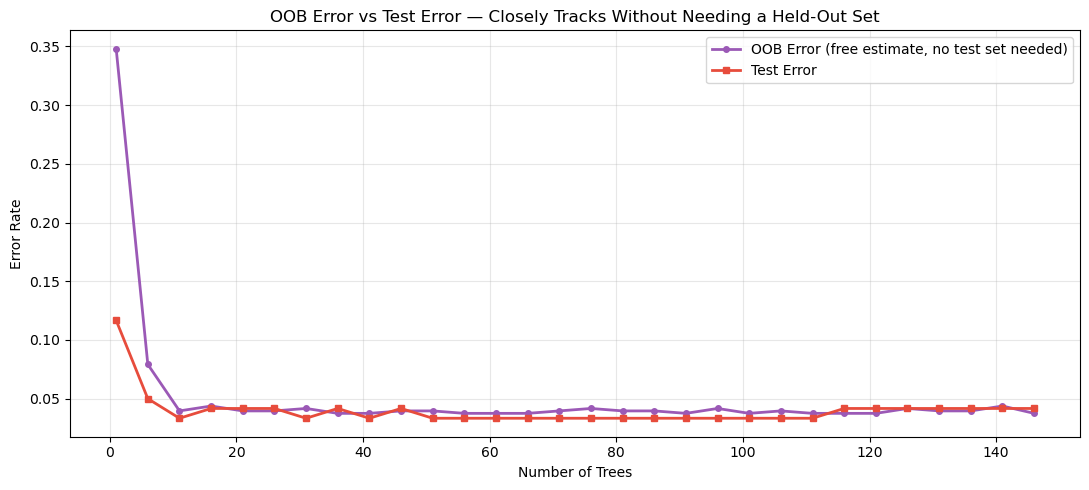

OOB error is a nearly unbiased estimate of generalization error.
This makes Random Forest unique — it has built-in cross-validation for free!


In [6]:
oob_errors  = []
test_errors = []
n_range     = range(1, 151, 5)

for n in n_range:
    clf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    oob_errors.append(1 - clf.oob_score_)
    test_errors.append(1 - accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(11, 5))
plt.plot(list(n_range), oob_errors,  'o-', color=COLORS['tertiary'],
         linewidth=2, markersize=4, label='OOB Error (free estimate, no test set needed)')
plt.plot(list(n_range), test_errors, 's-', color=COLORS['danger'],
         linewidth=2, markersize=4, label='Test Error')
plt.xlabel('Number of Trees')
plt.ylabel('Error Rate')
plt.title('OOB Error vs Test Error — Closely Tracks Without Needing a Held-Out Set')
plt.legend()
plt.tight_layout()
plt.show()

print('OOB error is a nearly unbiased estimate of generalization error.')
print('This makes Random Forest unique — it has built-in cross-validation for free!')

## 7. Feature Importance — MDI vs Permutation

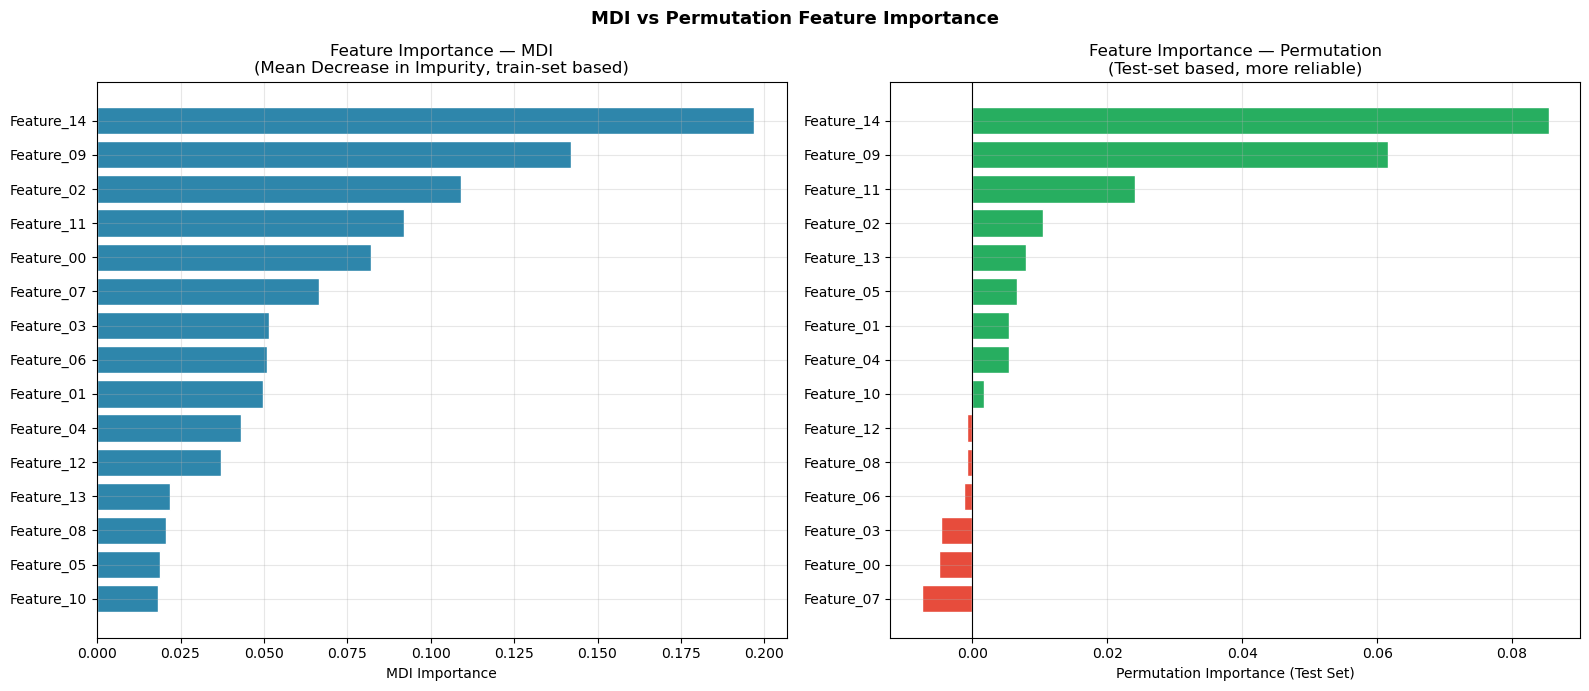

MDI can overestimate importance of high-cardinality features.
Permutation importance on the test set is generally more reliable.


In [7]:
# Multi-feature dataset for richer importance analysis
np.random.seed(10)
X_imp, y_imp = make_classification(
    n_samples=600, n_features=15, n_informative=7,
    n_redundant=4, random_state=10
)
feat_names = [f'Feature_{i:02d}' for i in range(15)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

rf_imp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp_tr, y_imp_tr)

# MDI (Mean Decrease in Impurity) — built-in
mdi_importance = rf_imp.feature_importances_

# Permutation importance — shuffle each feature and measure accuracy drop
perm_result = permutation_importance(
    rf_imp, X_imp_te, y_imp_te,
    n_repeats=20, random_state=42, n_jobs=-1
)
perm_importance = perm_result.importances_mean

imp_df = pd.DataFrame({
    'Feature':    feat_names,
    'MDI':        mdi_importance,
    'Permutation': perm_importance
}).sort_values('MDI', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(imp_df['Feature'], imp_df['MDI'],
             color=COLORS['primary'], edgecolor='white')
axes[0].set_xlabel('MDI Importance')
axes[0].set_title('Feature Importance — MDI\n(Mean Decrease in Impurity, train-set based)')

perm_sorted = imp_df.sort_values('Permutation', ascending=True)
colors_perm = [COLORS['success'] if v > 0 else COLORS['danger'] for v in perm_sorted['Permutation']]
axes[1].barh(perm_sorted['Feature'], perm_sorted['Permutation'],
             color=colors_perm, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Permutation Importance (Test Set)')
axes[1].set_title('Feature Importance — Permutation\n(Test-set based, more reliable)')

plt.suptitle('MDI vs Permutation Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('MDI can overestimate importance of high-cardinality features.')
print('Permutation importance on the test set is generally more reliable.')

## 8. Hyperparameter Tuning with GridSearchCV

Best Parameters   : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV ROC-AUC   : 0.9928
Test Accuracy     : 0.9667
Test ROC-AUC      : 0.9950
Test F1 Score     : 0.9667


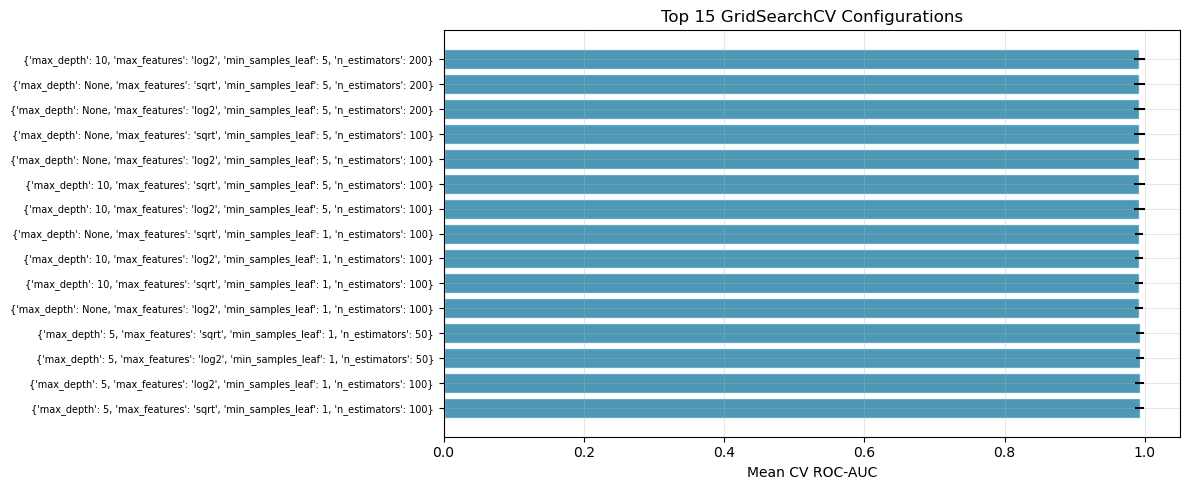

In [8]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=False),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

best_rf   = grid.best_estimator_
best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

print(f'Best Parameters   : {grid.best_params_}')
print(f'Best CV ROC-AUC   : {grid.best_score_:.4f}')
print(f'Test Accuracy     : {accuracy_score(y_test, best_pred):.4f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, best_prob):.4f}')
print(f'Test F1 Score     : {f1_score(y_test, best_pred):.4f}')

# Visualize grid results
cv_results = pd.DataFrame(grid.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.barh(range(len(cv_results)), cv_results['mean_test_score'],
         xerr=cv_results['std_test_score'],
         color=COLORS['primary'], edgecolor='white', alpha=0.85)
plt.yticks(range(len(cv_results)),
           [str(p) for p in cv_results['params']], fontsize=7)
plt.xlabel('Mean CV ROC-AUC')
plt.title('Top 15 GridSearchCV Configurations')
plt.tight_layout()
plt.show()

## 9. Random Forest Regressor

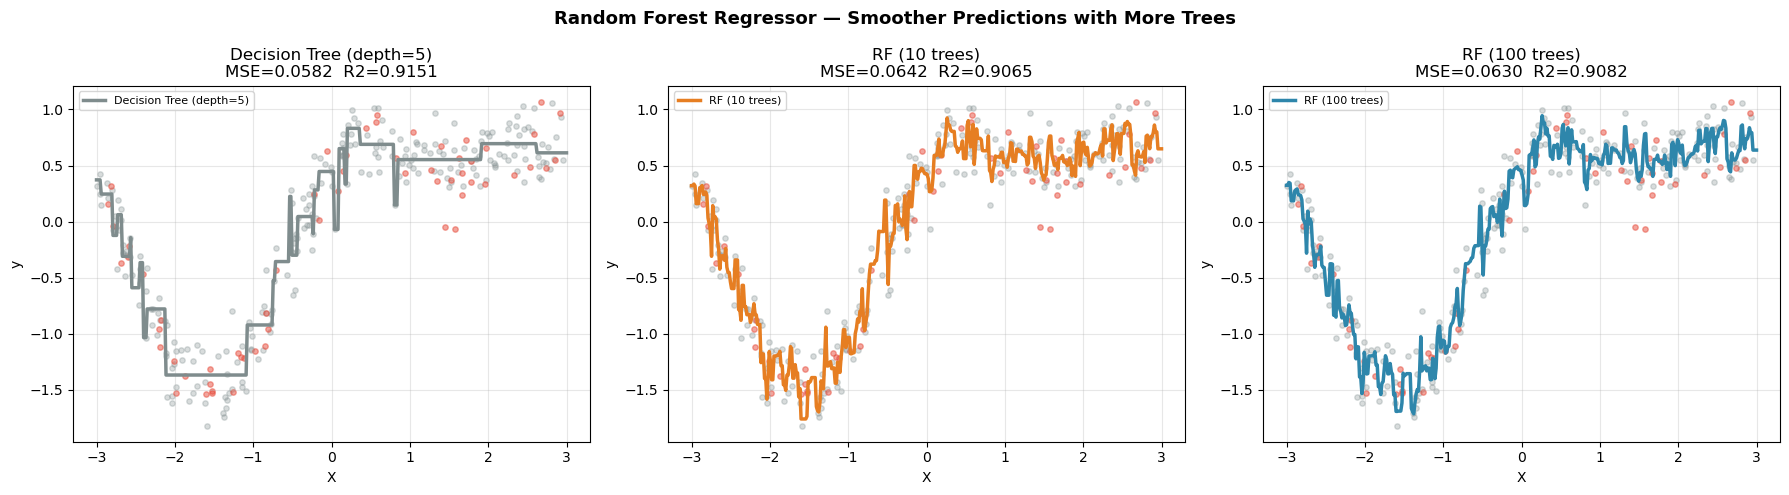

More trees -> smoother, more stable regression curve.
RF regression still predicts piecewise constants per tree,
but averaging hundreds produces an almost smooth curve.


In [9]:
np.random.seed(7)
X_r = np.sort(np.random.uniform(-3, 3, 300)).reshape(-1, 1)
y_r = np.sin(X_r).ravel() + 0.5*np.cos(2*X_r).ravel() + np.random.randn(300)*0.2

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

models_r = {
    'DT (depth=3)':     DecisionTreeClassifier.__class__,  # placeholder init below
}

from sklearn.tree import DecisionTreeRegressor

reg_models = {
    'Decision Tree (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RF (10 trees)':           RandomForestRegressor(n_estimators=10,  random_state=42, n_jobs=-1),
    'RF (100 trees)':          RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)
colors_r = [COLORS['neutral'], COLORS['secondary'], COLORS['primary']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model), color in zip(axes, reg_models.items(), colors_r):
    model.fit(X_r_tr, y_r_tr)
    test_mse = mean_squared_error(y_r_te, model.predict(X_r_te))
    test_r2  = r2_score(y_r_te, model.predict(X_r_te))

    ax.scatter(X_r_tr, y_r_tr, alpha=0.3, s=15, color=COLORS['neutral'])
    ax.scatter(X_r_te, y_r_te, alpha=0.5, s=15, color=COLORS['danger'])
    ax.plot(X_plot, model.predict(X_plot), color=color, linewidth=2.5, label=name)
    ax.set_title(f'{name}\nMSE={test_mse:.4f}  R2={test_r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Random Forest Regressor — Smoother Predictions with More Trees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('More trees -> smoother, more stable regression curve.')
print('RF regression still predicts piecewise constants per tree,')
print('but averaging hundreds produces an almost smooth curve.')

## 10. Real-World Offline-Safe Dataset — Credit Risk Prediction

In [10]:
np.random.seed(55)
n_cr = 1000

Age           = np.random.randint(20, 75, n_cr).astype(float)
Income        = np.random.uniform(15000, 200000, n_cr)
LoanAmount    = np.random.uniform(1000, 100000, n_cr)
CreditScore   = np.random.uniform(300, 850, n_cr)
ExistingDebt  = np.random.uniform(0, 60000, n_cr)
NumCreditLines= np.random.randint(0, 10, n_cr).astype(float)
LatePayments  = np.random.randint(0, 8, n_cr).astype(float)
YearsEmployed = np.random.uniform(0, 40, n_cr)
NumDependents = np.random.randint(0, 5, n_cr).astype(float)
SavingsBalance= np.random.uniform(0, 80000, n_cr)

feat_names_cr = ['Age','Income','LoanAmount','CreditScore','ExistingDebt',
                 'NumCreditLines','LatePayments','YearsEmployed',
                 'NumDependents','SavingsBalance']

X_cr = np.column_stack([Age, Income, LoanAmount, CreditScore, ExistingDebt,
                         NumCreditLines, LatePayments, YearsEmployed,
                         NumDependents, SavingsBalance])

log_odds = (-1 + 0.008*CreditScore - 0.00001*ExistingDebt
            + 0.00001*Income - 0.00001*LoanAmount
            - 0.15*LatePayments + 0.02*YearsEmployed
            + 0.00001*SavingsBalance)
prob_good = 1 / (1 + np.exp(-log_odds))
y_cr = (prob_good > np.random.uniform(0, 1, n_cr)).astype(int)

print(f'Dataset shape : {X_cr.shape}')
print(f'Class balance : {np.bincount(y_cr)}  (0=Default, 1=Good credit)')

X_cr_tr, X_cr_te, y_cr_tr, y_cr_te = train_test_split(
    X_cr, y_cr, test_size=0.2, random_state=42, stratify=y_cr
)

rf_cr = RandomForestClassifier(
    n_estimators=200, max_depth=10, max_features='sqrt',
    min_samples_leaf=5, oob_score=True, random_state=42, n_jobs=-1
)
rf_cr.fit(X_cr_tr, y_cr_tr)

cr_pred = rf_cr.predict(X_cr_te)
cr_prob = rf_cr.predict_proba(X_cr_te)[:, 1]

print(f'\nOOB Score     : {rf_cr.oob_score_:.4f}')
print(f'Test Accuracy : {accuracy_score(y_cr_te, cr_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_cr_te, cr_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_cr_te, cr_pred):.4f}')

# Cross-validation
cv_scores = cross_val_score(
    rf_cr, X_cr, y_cr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Dataset shape : (1000, 10)
Class balance : [ 33 967]  (0=Default, 1=Good credit)

OOB Score     : 0.9675
Test Accuracy : 0.9650
Test ROC-AUC  : 0.7691
Test F1 Score : 0.9822

5-Fold CV ROC-AUC: 0.7154 +/- 0.1143


## 11. Full Model Evaluation

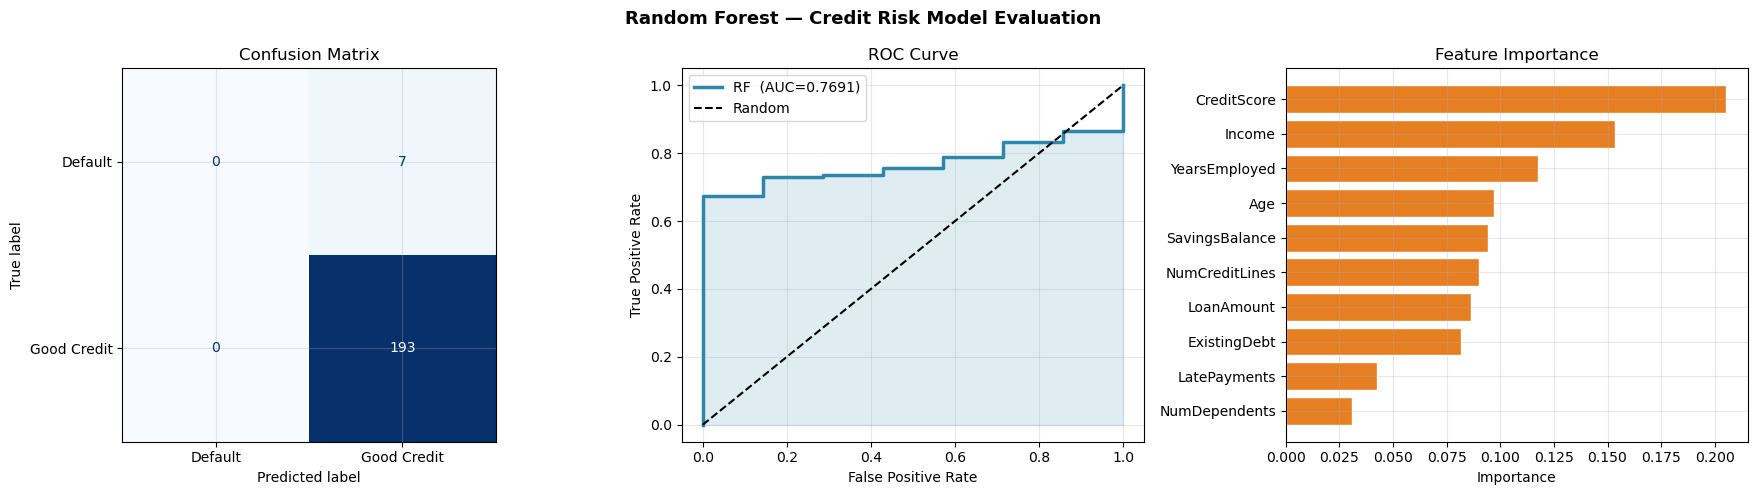


Classification Report:
              precision    recall  f1-score   support

     Default       0.00      0.00      0.00         7
 Good Credit       0.96      1.00      0.98       193

    accuracy                           0.96       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.93      0.96      0.95       200



In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_cr = confusion_matrix(y_cr_te, cr_pred)
ConfusionMatrixDisplay(cm_cr, display_labels=['Default','Good Credit']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_cr_te, cr_prob)
auc_cr = roc_auc_score(y_cr_te, cr_prob)
axes[1].plot(fpr, tpr, color=COLORS['primary'], linewidth=2.5,
             label=f'RF  (AUC={auc_cr:.4f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.15, color=COLORS['primary'])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature importance
imp_cr = pd.DataFrame({
    'Feature':    feat_names_cr,
    'Importance': rf_cr.feature_importances_
}).sort_values('Importance', ascending=True)

axes[2].barh(imp_cr['Feature'], imp_cr['Importance'],
             color=COLORS['secondary'], edgecolor='white')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance')

plt.suptitle('Random Forest — Credit Risk Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_cr_te, cr_pred, target_names=['Default','Good Credit']))

## 12. Random Forest vs Decision Tree — Head-to-Head

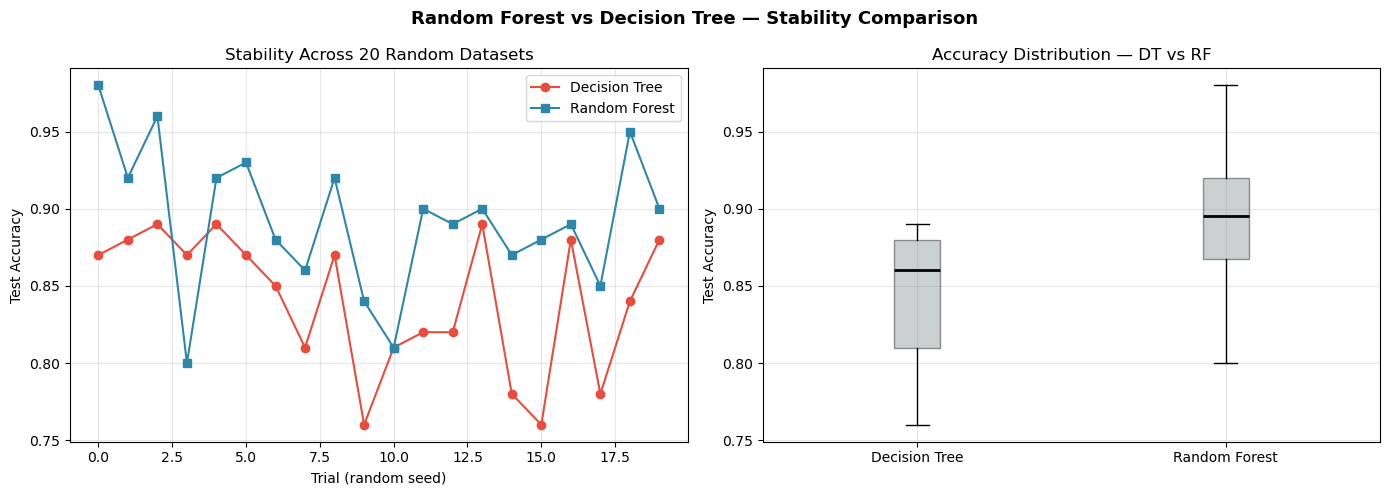

Decision Tree  mean=0.8410  std=0.0439
Random Forest  mean=0.8925  std=0.0454

RF Accuracy Gain : +5.15%
RF Variance Drop : --3.3%


In [12]:
from sklearn.tree import DecisionTreeClassifier

# Repeat experiment 20 times with different seeds to show stability
n_trials = 20
dt_scores  = []
rf_scores  = []

for seed in range(n_trials):
    X_t, y_t = make_classification(
        n_samples=500, n_features=10, n_informative=6,
        n_redundant=2, random_state=seed
    )
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=seed, stratify=y_t
    )
    dt = DecisionTreeClassifier(random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    dt.fit(X_tr, y_tr); rf.fit(X_tr, y_tr)
    dt_scores.append(accuracy_score(y_te, dt.predict(X_te)))
    rf_scores.append(accuracy_score(y_te, rf.predict(X_te)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dt_scores, 'o-', color=COLORS['danger'],   linewidth=1.5, label='Decision Tree')
axes[0].plot(rf_scores, 's-', color=COLORS['primary'],  linewidth=1.5, label='Random Forest')
axes[0].set_xlabel('Trial (random seed)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Stability Across 20 Random Datasets')
axes[0].legend()

axes[1].boxplot([dt_scores, rf_scores], labels=['Decision Tree','Random Forest'],
                patch_artist=True,
                boxprops=dict(facecolor=COLORS['neutral'], alpha=0.4),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy Distribution — DT vs RF')

plt.suptitle('Random Forest vs Decision Tree — Stability Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Decision Tree  mean={np.mean(dt_scores):.4f}  std={np.std(dt_scores):.4f}')
print(f'Random Forest  mean={np.mean(rf_scores):.4f}  std={np.std(rf_scores):.4f}')
print()
print(f'RF Accuracy Gain : +{(np.mean(rf_scores)-np.mean(dt_scores))*100:.2f}%')
print(f'RF Variance Drop : -{(1 - np.std(rf_scores)/np.std(dt_scores))*100:.1f}%')

## 13. Final Summary & Key Takeaways

In [13]:
print('=' * 66)
print('            RANDOM FOREST - KEY TAKEAWAYS')
print('=' * 66)

takeaways = [
    ('Ensemble method',   'Combines many trees via majority vote / averaging'),
    ('Bagging',           'Each tree trained on a bootstrap sample of data'),
    ('Feature randomness','Only sqrt(n) features considered at each split'),
    ('Variance reduction','Averaging decorrelated trees cancels out noise'),
    ('OOB score',         'Free built-in validation — no separate CV needed'),
    ('n_estimators',      'More trees -> more stable; ~100-200 usually sufficient'),
    ('max_features',      'Lower value -> more randomness -> more decorrelation'),
    ('Feature importance','MDI (fast) or Permutation (reliable) both available'),
    ('Feature scaling',   'NOT required — trees use raw thresholds'),
    ('Interpretability',  'Less interpretable than a single tree'),
    ('vs Decision Tree',  'Higher accuracy, lower variance, more stable predictions'),
    ('Weakness',          'Slower than single tree; harder to interpret; large memory'),
    ('Next step',         'Gradient Boosting (XGBoost, LightGBM) for even better accuracy'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<20}  ->  {detail}')

print('=' * 66)

            RANDOM FOREST - KEY TAKEAWAYS
  OK  Ensemble method       ->  Combines many trees via majority vote / averaging
  OK  Bagging               ->  Each tree trained on a bootstrap sample of data
  OK  Feature randomness    ->  Only sqrt(n) features considered at each split
  OK  Variance reduction    ->  Averaging decorrelated trees cancels out noise
  OK  OOB score             ->  Free built-in validation — no separate CV needed
  OK  n_estimators          ->  More trees -> more stable; ~100-200 usually sufficient
  OK  max_features          ->  Lower value -> more randomness -> more decorrelation
  OK  Feature importance    ->  MDI (fast) or Permutation (reliable) both available
  OK  Feature scaling       ->  NOT required — trees use raw thresholds
  OK  Interpretability      ->  Less interpretable than a single tree
  OK  vs Decision Tree      ->  Higher accuracy, lower variance, more stable predictions
  OK  Weakness              ->  Slower than single tree; harder to int

---
## Practice Exercises

1. **Vary max_features** from 1 to n_features and plot how OOB error changes.
2. **Compare OOB score vs 5-fold CV** — do they agree closely?
3. **Apply to an imbalanced dataset** using `class_weight='balanced'` and compare ROC-AUC.
4. **Compare MDI vs Permutation importance** — do rankings differ? Why?
5. **Plot individual tree predictions** vs the ensemble average for the regression task.
6. **Compare Random Forest vs Gradient Boosting** (sklearn's GradientBoostingClassifier) on the credit risk dataset.

---
*Notebook created for the ML Repository — Random Forest module.*